# CheXNet Reproduction 

## **Project Overview**


### **Objective**

The objective of this project is to reproduce the CheXNet architecture proposed by Stanford University for automated chest X-ray disease classification and pneumonia detection.

### **Motivation**

Pneumonia is one of the leading causes of mortality worldwide                         
Early diagnosis from chest X-ray images can significantly improve patient outcomes                                

### **Note**

The goal of this project was to reproduce the CheXNet methodology rather than exactly match the original paper's performance.                            

**Due to limited GPU resources and time constraints, training was restricted to 20 epochs**, which likely prevented the model from reaching full convergence and achieving the reported benchmark results.

In [ ]:
import os, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_auc_score, f1_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


# Configuration

In [ ]:

PATH_DIR_DATA  = "/kaggle/input/datasets/ammarkhanjadoon/chest-xray-14-dataset"
PATH_CSV       = "/kaggle/input/datasets/ammarkhanjadoon/chest-xray-14-dataset/Data_Entry_2017.csv"

PATH_TRAIN_CSV = "/kaggle/working/train.csv"
PATH_VAL_CSV   = "/kaggle/working/val.csv"
PATH_TEST_CSV  = "/kaggle/working/test.csv"
PATH_MODEL     = "/kaggle/working/best_model.pth"

NN_ARCHITECTURE = "DENSE-NET-121"
NN_IS_TRAINED   = True
NN_CLASS_COUNT  = 14

IMG_RESIZE = 256
IMG_CROP   = 224
BATCH_SIZE  = 32
MAX_EPOCHS  = 20
LR_INITIAL  = 1e-3
DATA_FRACTION = 1.0

In [ ]:
CLASSES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
PNEUMONIA_IDX = CLASS_TO_IDX["Pneumonia"]   # = 6  (used explicitly everywhere)

## Dataset Splitting

* **Load Dataset Metadata**

  * Read the ChestX-ray14 CSV file containing image information and disease labels.

* **Label Encoding**

  * Convert textual disease labels into multi-label binary vectors suitable for model training.

* **Official Dataset Split**

  * Use the official NIH train/validation and test image lists provided with the dataset.

* **Patient-Level Splitting**

  * Split the training data based on unique patient IDs rather than images.

* **Prevent Data Leakage**

  * Ensure that the same patient does not appear in both training and validation sets.
  * Verify that there is no overlap between training and test images.

*


In [ ]:
def build_splits(data_dir, csv_path):
    df = pd.read_csv(csv_path)
    df["labels"] = df["Finding Labels"].apply(encode_labels)

    train_val_list = open(f"{data_dir}/train_val_list.txt").read().splitlines()
    test_list      = open(f"{data_dir}/test_list.txt").read().splitlines()

    train_val_df = df[df["Image Index"].isin(train_val_list)].copy()
    test_df      = df[df["Image Index"].isin(test_list)].copy()

    train_val_patients = train_val_df["Patient ID"].unique()
    rng = np.random.default_rng(42)
    rng.shuffle(train_val_patients)
    split     = int(0.9 * len(train_val_patients))
    train_pts = train_val_patients[:split]
    val_pts   = train_val_patients[split:]

    train_df = train_val_df[train_val_df["Patient ID"].isin(train_pts)].copy()
    val_df   = train_val_df[train_val_df["Patient ID"].isin(val_pts)].copy()

    assert len(set(train_pts) & set(val_pts)) == 0, "Train/Val patient overlap!"
    assert len(set(train_val_list) & set(test_list)) == 0, "Train/Test image overlap!"

    pneu_train = train_df["Finding Labels"].str.contains("Pneumonia").sum()
    pneu_test  = test_df["Finding Labels"].str.contains("Pneumonia").sum()

    print(f"Train : {len(train_df):>6} images | {len(train_pts):>5} patients")
    print(f"Val   : {len(val_df):>6} images | {len(val_pts):>5} patients")
    print(f"Test  : {len(test_df):>6} images")
    print(f"Pneumonia — train: {pneu_train} ({100*pneu_train/len(train_df):.2f}%)  "
          f"test: {pneu_test} ({100*pneu_test/len(test_df):.2f}%)")

    train_df.to_csv(PATH_TRAIN_CSV, index=False)
    val_df.to_csv(PATH_VAL_CSV,     index=False)
    test_df.to_csv(PATH_TEST_CSV,   index=False)
    print("Saved train / val / test CSVs.")
    return train_df, val_df, test_df

In [ ]:
def encode_labels(x):
    y = [0] * len(CLASSES)
    labels = str(x).split("|")
    if "No Finding" in labels:
        return y
    for label in labels:
        if label in CLASS_TO_IDX:
            y[CLASS_TO_IDX[label]] = 1
    return y

## Custom Dataset Class

* **Load Dataset Metadata**

  * Read the dataset CSV file and load image labels associated with each chest X-ray image.

* **Prepare Multi-Label Targets**

  * Convert encoded disease labels into PyTorch tensors, enabling efficient multi-label classification training.


* **Image Loading and Standardization**

  * Load images from disk and convert them to RGB format to ensure compatibility with the pretrained DenseNet121 model, which expects 3-channel RGB inputs.

* **PyTorch Dataset Interface**

  * Implement `__len__()` and `__getitem__()` methods to integrate seamlessly with PyTorch DataLoaders.

* **Batch Processing Support**

  * Return images and labels in a format compatible with PyTorch DataLoaders, allowing automatic batching, shuffling, and parallel data loading during model training.

* **Output Format**

  * Return:

    * Input chest X-ray image
    * Corresponding multi-label disease vector


In [ ]:

class ChestXrayDataset(Dataset):

    def __init__(self, csv_path, image_dir, transform=None):
        self.df        = pd.read_csv(csv_path).reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self._image_map = None
        self.labels = torch.tensor(
            self.df["labels"].apply(eval).tolist(), dtype=torch.float32
        )

    def _get_map(self):
        if self._image_map is None:
            m = {}
            for root, _, files in os.walk(self.image_dir):
                for f in files:
                    if f.endswith(".png") or f.endswith(".jpg"):
                        m[f] = os.path.join(root, f)
            self._image_map = m
        return self._image_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "Image Index"]
        path     = self._get_map().get(img_name)
        if path is None:
            raise FileNotFoundError(f"Image not found: {img_name}")
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

## Why DenseNet-121?

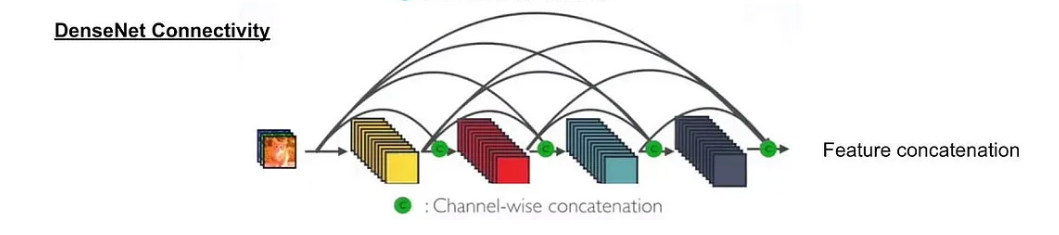

I selected **DenseNet-121** with for several reasons:

### 1. Proven Performance in Medical Imaging

DenseNet has been widely adopted in medical imaging tasks, especially **chest X-ray classification**, and has demonstrated strong empirical performance.

### 2. Addresses Limitations of Deep Networks

Deep neural networks often suffer from:

- **Vanishing Gradient Problem:** Gradients become very small in early layers during backpropagation.
- **Degradation Problem:** Increasing network depth does not always improve performance and may even hurt accuracy.

DenseNet mitigates these issues through **dense connectivity** between layers.

### 3. Feature Reuse

ResNet introduced **skip connections** to improve gradient flow. However, each layer mainly uses information from the previous layer.

DenseNet extends this idea by connecting **each layer to all preceding layers**, enabling **feature reuse** throughout the network.

This is particularly useful in medical imaging, where low-level features (such as **edges and textures**) remain important for later layers.

### 4. Transition Layers

DenseNet uses **transition layers** between dense blocks to reduce feature map dimensions and control computational cost, making the architecture more efficient.
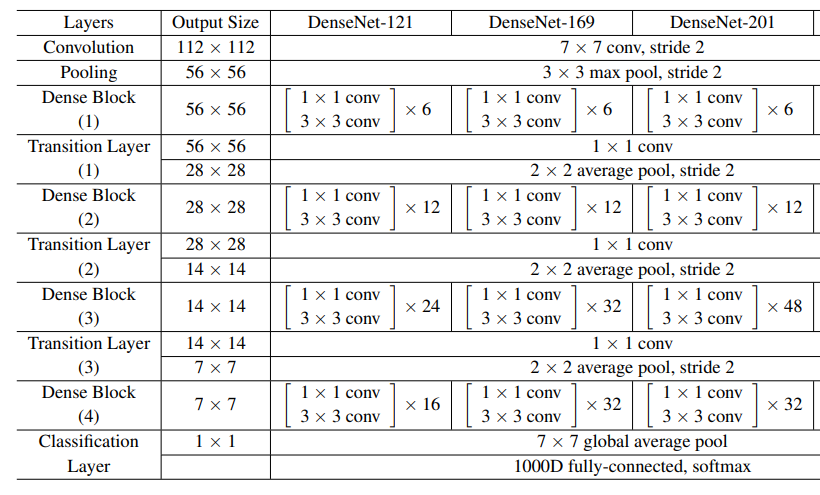

### 5. Parameter Efficiency

Because features are reused instead of repeatedly relearned, DenseNet achieves strong performance with **fewer parameters** compared to many other deep architectures.

## Model Architecture

* **Transfer Learning**

  * Initialize DenseNet121  with ImageNet pretrained weights.

* **Custom Output Layer**

  * Replace the original classifier with a 14-neuron layer to match the ChestX-ray14 disease classes.

* **Multi-Label Classification**

  * Enable prediction of multiple diseases from a single chest X-ray image.

* **Model Selection**

  * Provide a unified interface for switching between DenseNet121 and ResNet18 during experimentation.

* **Device Allocation**

  * Automatically move the model to the available GPU or CPU.


In [ ]:
class DenseNet121(nn.Module):
    def __init__(self, class_count=14, pretrained=True):
        super().__init__()
        weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        self.net = models.densenet121(weights=weights)
        in_features = self.net.classifier.in_features
        self.net.classifier = nn.Linear(in_features, class_count)

    def forward(self, x):
        return self.net(x)


class ResNet18(nn.Module):
    def __init__(self, class_count=14, pretrained=True):
        super().__init__()
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        self.net = models.resnet18(weights=weights)
        in_features = self.net.fc.in_features
        self.net.fc = nn.Linear(in_features, class_count)

    def forward(self, x):
        return self.net(x)


def build_model(arch, class_count, pretrained):
    if arch == "DENSE-NET-121":
        return DenseNet121(class_count, pretrained).to(device)
    if arch == "RES-NET-18":
        return ResNet18(class_count, pretrained).to(device)
    raise ValueError(f"Unknown architecture: {arch}")

## Data Preprocessing & Augmentation

* ### Image Normalization

    Applied **ImageNet normalization** using predefined mean and standard deviation values.

    This ensures that input distributions remain consistent with the **pre-trained model initialization**, enabling more stable and effective transfer learning.

* ### Training Transformations

  The following augmentations were applied during training:

  - **RandomResizedCrop (224 × 224)** to improve robustness against variations in image scale and positioning.
  - **RandomHorizontalFlip** to increase data diversity and reduce overfitting.
  - Conversion to **tensor** followed by **normalization**.

* ### Validation Transformations

    Validation preprocessing follows a deterministic pipeline:

    - **Resize → CenterCrop**
    - No random augmentations are applied.

    This ensures **fair and reproducible performance evaluation** across validation runs.

* ### Test-Time Augmentation (TTA)

    Applied **TenCrop evaluation**, generating **ten different crops** from each image.

    Predictions from multiple views are aggregated to obtain a **more stable and reliable final prediction**.

    This often improves **AUROC** by reducing sensitivity to image positioning.


In [ ]:
_normalize = transforms.Normalize([0.485, 0.456, 0.406],
                                   [0.229, 0.224, 0.225])

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(IMG_CROP),   # paper uses random crop
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    _normalize,
])

transform_val = transforms.Compose([
    transforms.Resize(IMG_RESIZE),            # 256
    transforms.CenterCrop(IMG_CROP),          # 224
    transforms.ToTensor(),
    _normalize,
])

# TenCrop for test-time augmentation (improves AUROC)
transform_test_tencrop = transforms.Compose([
    transforms.Resize(IMG_RESIZE),
    transforms.TenCrop(IMG_CROP),
    transforms.Lambda(lambda crops: torch.stack(
        [transforms.Compose([transforms.ToTensor(), _normalize])(c) for c in crops]
    )),
])




## Evaluation Strategy & Metrics





* ### ROC-AUC (Primary Metric)

  ROC-AUC measures how well the model separates **positive vs negative cases** across all thresholds.

  Why used:

  - Threshold-independent  
  - Robust to class imbalance  
  - Standard metric in medical imaging  

  For evaluation:

  - Compute **AUC per disease (one-vs-rest)**
  - Report **macro-average AUROC**

  **Interpretation:**  
  Higher AUROC → better disease discrimination.



* ### F1-Score (Secondary Metric)

  Used only for **Pneumonia** to evaluate performance at a chosen threshold.

  Why:

  - Reflects **precision–recall trade-off**
  - Supports threshold tuning
  - Simulates clinical decisions



* ### Bootstrap Confidence Interval

  To measure metric reliability:

  - Resample test data multiple times  
  - Recompute AUROC  
  - Report:
    - Mean AUROC  
    - Standard deviation  
    - 95% Confidence Interval  

  **Interpretation:**  
  Narrow CI → stable model.







In [ ]:

class Metrics:

    @staticmethod
    def compute_auroc(y_true, y_prob, class_count):
        y_true = y_true.detach().cpu().numpy()
        y_prob = y_prob.detach().cpu().numpy()
        aurocs = []
        for c in range(class_count):
            gt, prob = y_true[:, c], y_prob[:, c]
            if len(np.unique(gt)) < 2:
                aurocs.append(float("nan"))
            else:
                aurocs.append(roc_auc_score(gt, prob))
        return aurocs

    @staticmethod
    def compute_pneumonia_f1(y_true, y_prob, pneumonia_idx=PNEUMONIA_IDX):
        y_true = y_true.detach().cpu().numpy()[:, pneumonia_idx]
        y_prob = y_prob.detach().cpu().numpy()[:, pneumonia_idx]
        thresholds = np.linspace(0.05, 0.9, 50)
        f1_list = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
                   for t in thresholds]
        best_i = int(np.argmax(f1_list))
        return f1_list[best_i], thresholds[best_i]

    @staticmethod
    def bootstrap_auroc(y_true, y_prob, class_count, n_boot=1000, seed=42):
        y_true = y_true.detach().cpu().numpy()
        y_prob = y_prob.detach().cpu().numpy()
        rng = np.random.default_rng(seed)
        N = len(y_true)
        scores = []
        for _ in range(n_boot):
            idx = rng.choice(N, N, replace=True)
            row = []
            for c in range(class_count):
                gt, prob = y_true[idx, c], y_prob[idx, c]
                if len(np.unique(gt)) < 2:
                    row.append(float("nan"))
                else:
                    row.append(roc_auc_score(gt, prob))
            scores.append(row)
        scores = np.array(scores)
        return {
            "mean":  np.nanmean(scores, axis=0),
            "std":   np.nanstd(scores, axis=0),
            "lower": np.nanpercentile(scores, 2.5,  axis=0),
            "upper": np.nanpercentile(scores, 97.5, axis=0),
        }



## Training & Inference Pipeline

* ### Training

  Standard supervised training pipeline:

  - `model.train()` enables training mode  
  - Compute gradients via backpropagation  
  - Update weights using optimizer  
  - Accumulate loss across batches  

  This enables end-to-end learning.



* ### Validation

  Evaluation pipeline:

  - `model.eval()` disables training behavior  
  - `torch.no_grad()` disables gradient computation  
  - Forward pass only  
  - Compute validation loss without updating weights  

  Ensures fair generalization evaluation.



* ### Standard Inference

  Baseline prediction pipeline:

  - Each image is processed once  
  - Collect logits directly  
  - Store predictions and ground truth for evaluation  

  Fast and efficient inference.



* ### Test-Time Augmentation (TenCrop)

  Instead of one image view:

  - Generate **10 crops** (corners + center + flips)  
  - Run inference on all crops  
  - Average predictions  

  Input shape:

  ```text
  (B × 10, C, H, W)
  ````

  Benefits:

  * Reduces spatial bias
  * Improves prediction stability
  * Often improves AUROC




In [ ]:

def epoch_train(model, loader, optimizer, loss_fn):
    model.train()
    total = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)


def epoch_val(model, loader, loss_fn):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            total += loss_fn(model(imgs), labels).item()
    return total / len(loader)


def get_outputs(model, loader):
    """Standard (non-TenCrop) inference."""
    model.eval()
    gts, preds = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            gts.append(labels)
            preds.append(model(imgs).cpu())
    return torch.cat(gts), torch.cat(preds)


def get_outputs_tencrop(model, loader):
    """TenCrop inference — averages logits across 10 crops."""
    model.eval()
    gts, preds = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            # imgs shape: (B, 10, C, H, W)
            B, n_crops, C, H, W = imgs.size()
            imgs = imgs.view(-1, C, H, W).to(device)           # (B*10, C, H, W)
            out  = model(imgs).view(B, n_crops, -1).mean(dim=1) # (B, 14)
            gts.append(labels)
            preds.append(out.cpu())
    return torch.cat(gts), torch.cat(preds)



## Training Strategy

* ### Data Loading

  - Separate **training** and **validation** datasets  
  - Shuffle training batches for better generalization  
  - Keep validation fixed for consistent evaluation  


* ### Handling Class Imbalance

    To address severe imbalance:

  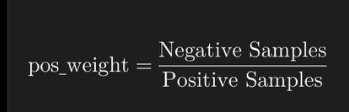   \[

    These weights are applied in **BCEWithLogitsLoss** to emphasize rare diseases.



* ### Loss Function — BCEWithLogitsLoss

  Selected because:

  - Supports **multi-label classification**
  - Allows multiple diseases per image
  - Treats each class independently
  - More numerically stable than **Sigmoid + BCE**



* ### Optimization

  **Adam Optimizer**

  - Learning Rate = `1e-3`
  - Weight Decay = `1e-5`

  Chosen for efficient and adaptive optimization.



* ### Learning Rate Scheduling

  **ReduceLROnPlateau**

  - Monitor validation loss  
  - Reduce learning rate ×10 when improvement stops  

  Helps refine convergence.



* ### Model Selection & Early Stopping

  - Save checkpoint with **lowest validation loss**
  - Stop training after **3 epochs without improvement**

  Benefits:

  - Reduces overfitting  
  - Saves computation  



In [ ]:

def train(
    path_dir_data, path_train, path_val,
    arch=NN_ARCHITECTURE,
    pretrained=NN_IS_TRAINED,
    class_count=NN_CLASS_COUNT,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    lr=LR_INITIAL,
    checkpoint=None,
):
    model = build_model(arch, class_count, pretrained)

    if checkpoint:
        model.load_state_dict(torch.load(checkpoint, map_location=device))
        print(f"Resumed from {checkpoint}")

    num_workers = 4 if torch.cuda.is_available() else 0

    ds_train = ChestXrayDataset(path_train, path_dir_data, transform_train)
    ds_val   = ChestXrayDataset(path_val,   path_dir_data, transform_val)

    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    loader_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    pos_weight = compute_pos_weight(path_train)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = optim.Adam(model.parameters(), lr=lr,
                            betas=(0.9, 0.999), weight_decay=1e-5)
    scheduler  = ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=1)

    PATIENCE_EARLY_STOP = 3
    epochs_no_improve   = 0
    best_val_loss       = float("inf")

    print(f"\nTraining {arch} for up to {max_epochs} epochs on {device}")
    print("=" * 60)

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()

        train_loss = epoch_train(model, loader_train, optimizer, loss_fn)
        val_loss   = epoch_val(model, loader_val, loss_fn)
        scheduler.step(val_loss)

        gt, pred   = get_outputs(model, loader_val)
        aurocs     = Metrics.compute_auroc(gt, pred, class_count)
        mean_auc   = float(np.nanmean(aurocs))
        current_lr = optimizer.param_groups[0]["lr"]
        elapsed    = time.time() - t0

        tag = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), PATH_MODEL)
            tag = "  ← SAVED"
        else:
            epochs_no_improve += 1
            tag = f"  (no improve {epochs_no_improve}/{PATIENCE_EARLY_STOP})"

        print(f"Epoch {epoch:02d}/{max_epochs} | "
              f"TrainLoss={train_loss:.4f} | ValLoss={val_loss:.4f} | "
              f"ValAUC={mean_auc:.4f} | LR={current_lr:.0e} | "
              f"{elapsed/60:.1f}min{tag}")

        if epochs_no_improve >= PATIENCE_EARLY_STOP:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    print(f"\nBest val loss: {best_val_loss:.4f}  →  model saved to {PATH_MODEL}")
    return model

In [ ]:
def compute_pos_weight(train_csv):
    df = pd.read_csv(train_csv)
    label_matrix = np.vstack(df["labels"].apply(eval).values)
    pos = label_matrix.sum(axis=0)
    neg = len(label_matrix) - pos
    pos_weight = np.where(pos > 0, neg / pos, 1.0)
    return torch.tensor(pos_weight, dtype=torch.float32).to(device)



In [ ]:

def test(
    path_dir_data, path_test,
    path_model=PATH_MODEL,
    arch=NN_ARCHITECTURE,
    class_count=NN_CLASS_COUNT,
    pretrained=NN_IS_TRAINED,
    batch_size=BATCH_SIZE,
    use_tencrop=True,
):
    model = build_model(arch, class_count, pretrained)
    model.load_state_dict(torch.load(path_model, map_location=device))
    model.eval()

    tf     = transform_test_tencrop if use_tencrop else transform_val
    ds     = ChestXrayDataset(path_test, path_dir_data, tf)
    num_workers = 4 if torch.cuda.is_available() else 0
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

    if use_tencrop:
        gt, pred = get_outputs_tencrop(model, loader)
    else:
        gt, pred = get_outputs(model, loader)

    aurocs   = Metrics.compute_auroc(gt, pred, class_count)
    mean_auc = float(np.nanmean(aurocs))

    print("\n" + "=" * 60)
    print("Per-class AUROC (paper targets in parentheses):")
    paper_auroc = [0.8094, 0.9248, 0.8638, 0.7345, 0.8676,
                   0.7802, 0.7680, 0.8887, 0.7901, 0.8878,
                   0.9371, 0.8047, 0.8062, 0.9164]
    for i, (cls, auc, ref) in enumerate(zip(CLASSES, aurocs, paper_auroc)):
        flag = "✓" if (not np.isnan(auc) and auc >= ref - 0.02) else "✗"
        print(f"  {flag} {cls:<20} {auc:.4f}  (paper: {ref:.4f})")

    print(f"\nMean AUROC:  {mean_auc:.4f}   (paper: 0.8417)")

    f1, thr = Metrics.compute_pneumonia_f1(gt, pred, PNEUMONIA_IDX)
    print(f"Pneumonia F1: {f1:.4f} @ threshold {thr:.3f}   (paper: 0.435)")

    # Bootstrap 95% CI
    boot = Metrics.bootstrap_auroc(gt, pred, class_count, n_boot=2000)
    print("\nBootstrap 95% CI (mean AUROC):")
    mean_lower = float(np.nanmean(boot["lower"]))
    mean_upper = float(np.nanmean(boot["upper"]))
    print(f"  [{mean_lower:.4f}, {mean_upper:.4f}]")

    return aurocs, mean_auc, f1


In [ ]:

if __name__ == "__main__":

    build_splits(PATH_DIR_DATA, PATH_CSV)

    train(
        path_dir_data=PATH_DIR_DATA,
        path_train=PATH_TRAIN_CSV,
        path_val=PATH_VAL_CSV,
    )

    test(
        path_dir_data=PATH_DIR_DATA,
        path_test=PATH_TEST_CSV,
        use_tencrop=True,
    )

Train :  77921 images | 25207 patients
Val   :   8603 images |  2801 patients
Test  :  25596 images
Pneumonia — train: 794 (1.02%)  test: 555 (2.17%)
Saved train / val / test CSVs.
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 184MB/s]



Training DENSE-NET-121 for up to 20 epochs on cuda
Epoch 01/20 | TrainLoss=1.3503 | ValLoss=1.3052 | ValAUC=0.6039 | LR=1e-03 | 20.0min  ← SAVED
Epoch 02/20 | TrainLoss=1.3203 | ValLoss=1.2998 | ValAUC=0.5807 | LR=1e-03 | 17.6min  ← SAVED
Epoch 03/20 | TrainLoss=1.3009 | ValLoss=1.2870 | ValAUC=0.6205 | LR=1e-03 | 16.9min  ← SAVED
Epoch 04/20 | TrainLoss=1.2816 | ValLoss=1.2497 | ValAUC=0.6409 | LR=1e-03 | 17.9min  ← SAVED
Epoch 05/20 | TrainLoss=1.2768 | ValLoss=1.2337 | ValAUC=0.6589 | LR=1e-03 | 16.7min  ← SAVED
Epoch 06/20 | TrainLoss=1.2638 | ValLoss=1.2526 | ValAUC=0.6626 | LR=1e-03 | 16.8min  (no improve 1/3)
Epoch 07/20 | TrainLoss=1.2577 | ValLoss=1.4115 | ValAUC=0.6137 | LR=1e-04 | 16.4min  (no improve 2/3)
Epoch 08/20 | TrainLoss=1.2315 | ValLoss=1.1915 | ValAUC=0.6932 | LR=1e-04 | 16.6min  ← SAVED
Epoch 09/20 | TrainLoss=1.2177 | ValLoss=1.1829 | ValAUC=0.6995 | LR=1e-04 | 16.7min  ← SAVED
Epoch 10/20 | TrainLoss=1.2146 | ValLoss=1.1666 | ValAUC=0.7096 | LR=1e-04 | 16.5min

## **Results**

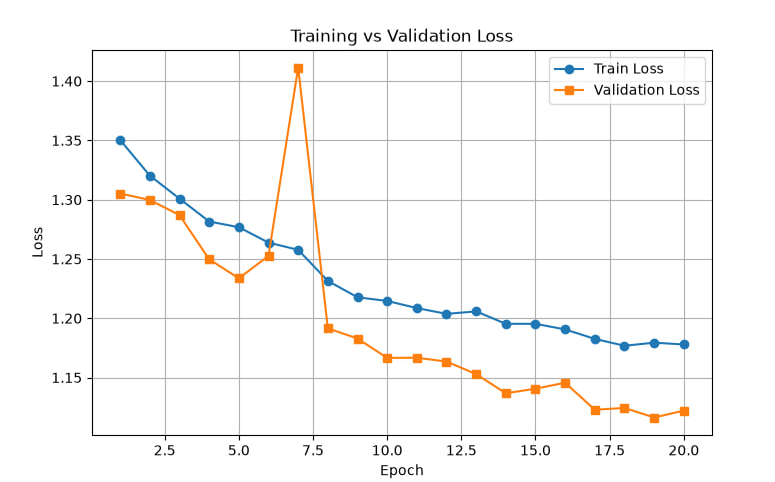

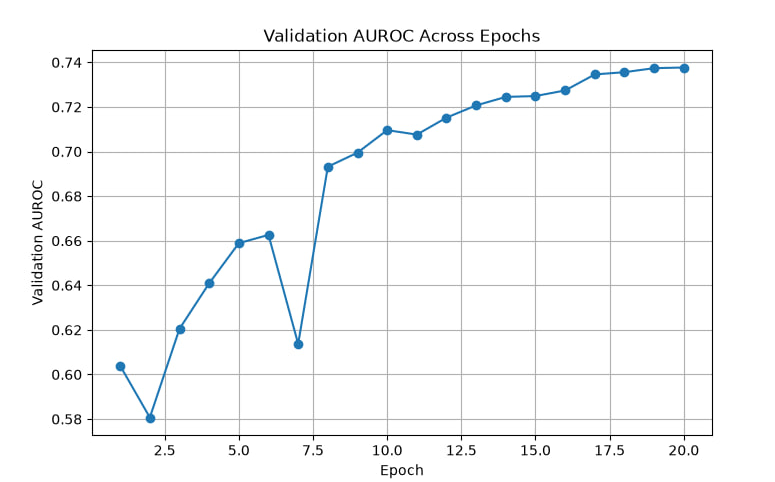

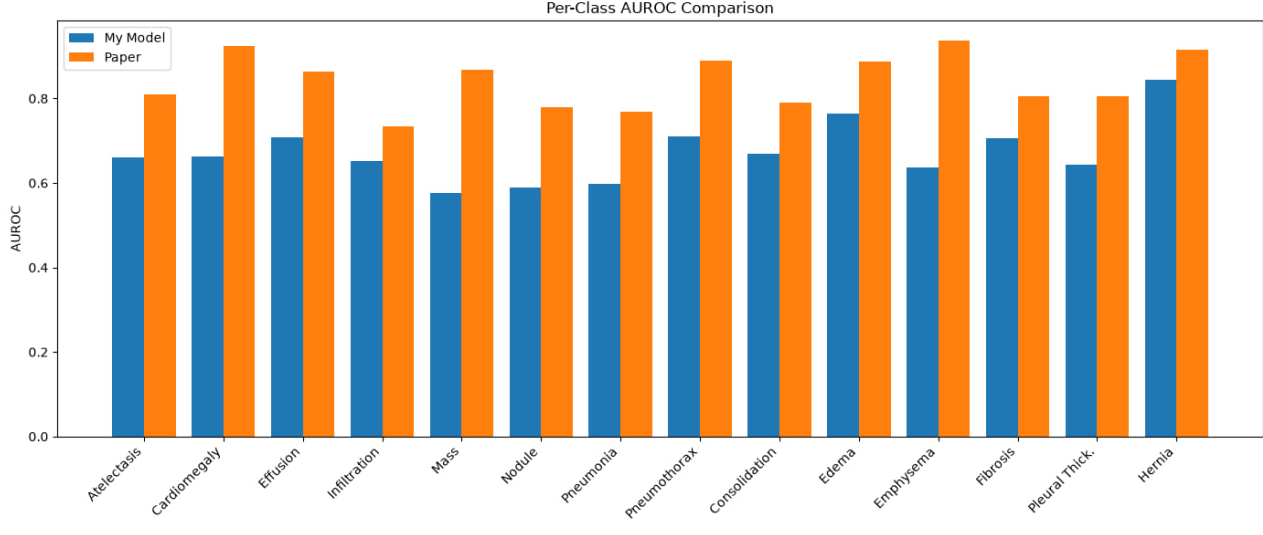

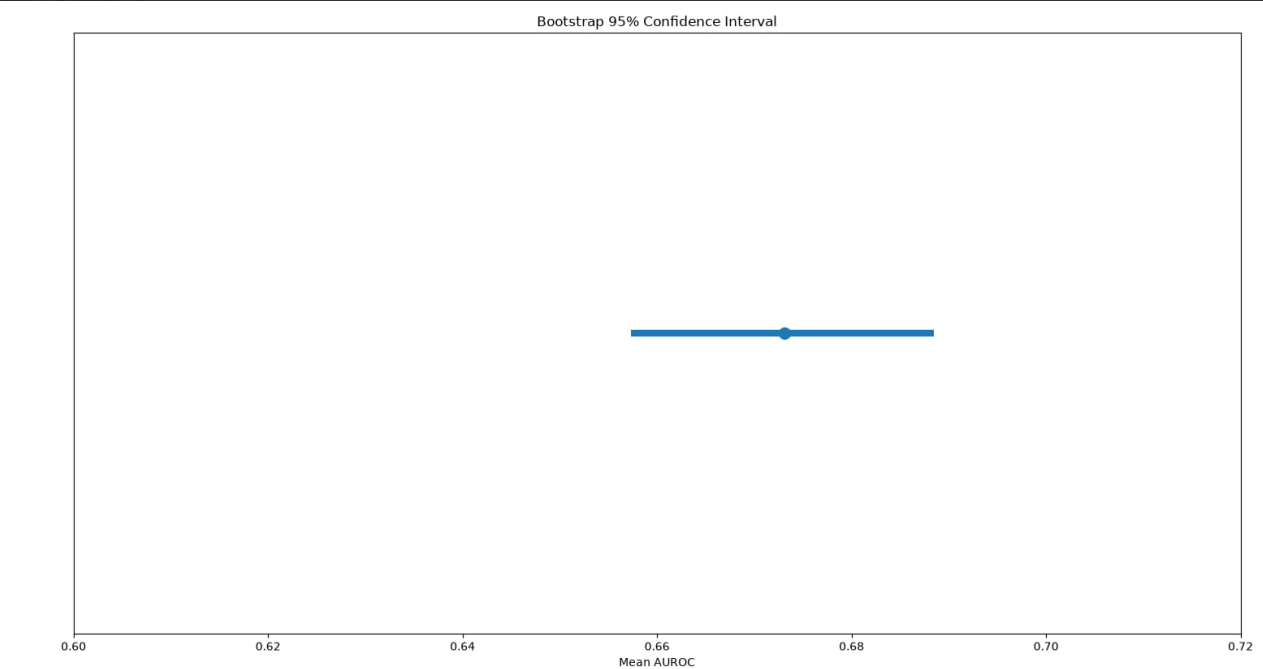